In [5]:
import pandas as pd

base = "../experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/"

dim_probe = pd.read_csv(base + "dim_probe.csv")
dim_site  = pd.read_csv(base + "dim_site.csv")
fact_trace = pd.read_csv(base + "fact_trace.csv")
fact_ping  = pd.read_csv(base + "fact_ping.csv")
fact_hop   = pd.read_csv(base + "fact_hop.csv")

print(dim_probe.shape, dim_site.shape, fact_trace.shape, fact_ping.shape, fact_hop.shape)

(8, 7) (10, 4) (14319, 18) (42823, 12) (152019, 10)


In [6]:
# join traces with probe and site info
traces = fact_trace.merge(dim_probe, on="probe_id").merge(dim_site, on="site_id")

print(traces.shape)
print(traces.columns.tolist())

(14319, 27)
['trace_id', 'trace_time', 'probe_id', 'site_id', 'probe_asn_measured', 'target_ip', 'target_asn', 'target_asn_name', 'target_country', 'dest_rtt_ms', 'total_hops', 'timeout_hops', 'asns_in_path', 'countries_in_path', 'dest_location', 'location_via', 'destination_responded', 'measurement_id', 'label', 'isp', 'city', 'city_code', 'asn_registered', 'probe_ip', 'target_label', 'target_hostname', 'target_category']


In [7]:
traces.head(10)

,trace_id,trace_time,probe_id,site_id,probe_asn_measured,target_ip,target_asn,target_asn_name,target_country,dest_rtt_ms,...,measurement_id,label,isp,city,city_code,asn_registered,probe_ip,target_label,target_hostname,target_category
0,1,2026-06-14T14:25:33+00:00,62224,5,38193,103.125.60.60,138424,"FBR-AS-AP - Federal Board of Revenue, PK",PK,NaN,...,180055861,transworld.lhe (AS38193),transworld,Lahore,lhe,38193,110.93.235.222,FBR,fbr.gov.pk,government
1,2,2026-06-14T14:25:34+00:00,7613,4,152605,172.67.174.102,13335,"CLOUDFLARENET - Cloudflare, Inc., US",US,142.412,...,180055870,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16,Express,express.com.pk,news
2,3,2026-06-14T14:25:39+00:00,7764,1,17557,47.246.167.168,45102,"ALIBABA-CN-NET - Alibaba (US) Technology Co., ...",US,104.158,...,180055878,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50,Daraz,daraz.pk,ecommerce
3,4,2026-06-14T14:25:40+00:00,1016126,8,17557,192.124.249.159,30148,"SUCURI-SEC - Sucuri, US",US,226.000,...,180055894,ptcl.khi (AS17557),ptcl,Karachi,khi,17557,39.39.48.53,MCB Bank,mcb.com.pk,banking
4,5,2026-06-14T14:25:41+00:00,60223,5,23674,103.125.60.60,138424,"FBR-AS-AP - Federal Board of Revenue, PK",PK,NaN,...,180055861,nayatel.isb (AS23674),nayatel,Islamabad,isb,23674,154.192.10.60,FBR,fbr.gov.pk,government
5,6,2026-06-14T14:25:41+00:00,1015679,9,136174,2.19.193.138,20940,"AKAMAI-ASN1 - Akamai International B.V., NL",NL,170.877,...,180055898,nova.lhe (AS136174),nova,Lahore,lhe,136174,103.184.1.10,NADRA,nadra.gov.pk,government
6,7,2026-06-14T14:25:42+00:00,1015679,8,136174,192.124.249.159,30148,"SUCURI-SEC - Sucuri, US",US,139.669,...,180055894,nova.lhe (AS136174),nova,Lahore,lhe,136174,103.184.1.10,MCB Bank,mcb.com.pk,banking
7,8,2026-06-14T14:25:43+00:00,7613,9,152605,2.19.193.138,20940,"AKAMAI-ASN1 - Akamai International B.V., NL",NL,169.045,...,180055898,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16,NADRA,nadra.gov.pk,government
8,9,2026-06-14T14:25:43+00:00,1016126,9,17557,2.19.193.138,20940,"AKAMAI-ASN1 - Akamai International B.V., NL",NL,242.052,...,180055898,ptcl.khi (AS17557),ptcl,Karachi,khi,17557,39.39.48.53,NADRA,nadra.gov.pk,government
9,10,2026-06-14T14:25:48+00:00,7764,7,17557,45.60.109.176,19551,"INCAPSULA - Incapsula Inc, US",US,226.063,...,180055882,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50,HBL Bank,hbl.com,banking


In [8]:
print("=== Unique values ===")
print("Probes:", traces['isp'].unique())
print("Sites:", traces['target_hostname'].unique())
print("Time range:", traces['trace_time'].min(), "to", traces['trace_time'].max())
print("\n=== RTT summary (ms) ===")
print(traces['dest_rtt_ms'].describe())
print("\n=== How many responded vs not ===")
print(traces['destination_responded'].value_counts())

=== Unique values ===
Probes: <StringArray>
['transworld', 'zcom', 'ptcl', 'nayatel', 'nova', 'cybernet']
Length: 6, dtype: str
Sites: <StringArray>
[    'fbr.gov.pk', 'express.com.pk',       'daraz.pk',     'mcb.com.pk',
   'nadra.gov.pk',        'hbl.com',       'dawn.com',         'geo.tv',
   'dunyanews.tv',    'telemart.pk']
Length: 10, dtype: str
Time range: 2026-06-14T14:25:33+00:00 to 2026-06-16T14:16:46+00:00

=== RTT summary (ms) ===
count    10702.000000
mean       120.826439
std         86.675212
min          2.060000
25%         24.497000
50%        112.182000
75%        183.577250
max        436.298000
Name: dest_rtt_ms, dtype: float64

=== How many responded vs not ===
destination_responded
True     10702
False     3617
Name: count, dtype: int64


In [9]:
# median RTT per ISP across all sites
isp_rtt = traces.groupby('isp')['dest_rtt_ms'].median().sort_values()
print(isp_rtt)

isp
cybernet       80.4570
zcom           94.8180
nayatel        98.1730
nova           99.0205
transworld     99.6320
ptcl          211.4930
Name: dest_rtt_ms, dtype: float64


In [10]:
# where is each site hosted according to the traceroute data
site_hosting = traces.groupby('target_hostname')['target_country'].agg(lambda x: x.mode()[0])
print(site_hosting)


target_hostname
daraz.pk          US
dawn.com          US
dunyanews.tv      PK
express.com.pk    US
fbr.gov.pk        PK
geo.tv            US
hbl.com           US
mcb.com.pk        US
nadra.gov.pk      NL
telemart.pk       US
Name: target_country, dtype: str


In [11]:
# split sites into PK-hosted vs CDN/foreign
pk_hosted = ['dunyanews.tv', 'fbr.gov.pk']
cdn_local = ['dawn.com', 'geo.tv']  # Cloudflare served locally for most ISPs
foreign = ['daraz.pk', 'hbl.com', 'mcb.com.pk', 'nadra.gov.pk', 'express.com.pk', 'telemart.pk']

# median RTT per ISP for PK-hosted sites only
print("=== PK-hosted sites ===")
pk_mask = traces['target_hostname'].isin(pk_hosted)
print(traces[pk_mask].groupby('isp')['dest_rtt_ms'].median().sort_values())

print("\n=== CDN (locally served) sites ===")
cdn_mask = traces['target_hostname'].isin(cdn_local)
print(traces[cdn_mask].groupby('isp')['dest_rtt_ms'].median().sort_values())

print("\n=== Foreign-hosted sites ===")
foreign_mask = traces['target_hostname'].isin(foreign)
print(traces[foreign_mask].groupby('isp')['dest_rtt_ms'].median().sort_values())

=== PK-hosted sites ===
isp
cybernet     NaN
nayatel      NaN
nova         NaN
ptcl         NaN
transworld   NaN
zcom         NaN
Name: dest_rtt_ms, dtype: float64

=== CDN (locally served) sites ===
isp
nayatel         3.0550
zcom           17.3055
nova           19.3820
transworld     23.4505
cybernet       24.1600
ptcl          132.9050
Name: dest_rtt_ms, dtype: float64

=== Foreign-hosted sites ===
isp
nayatel       114.2340
zcom          130.1300
nova          131.9145
transworld    136.3465
cybernet      140.1385
ptcl          211.9060
Name: dest_rtt_ms, dtype: float64


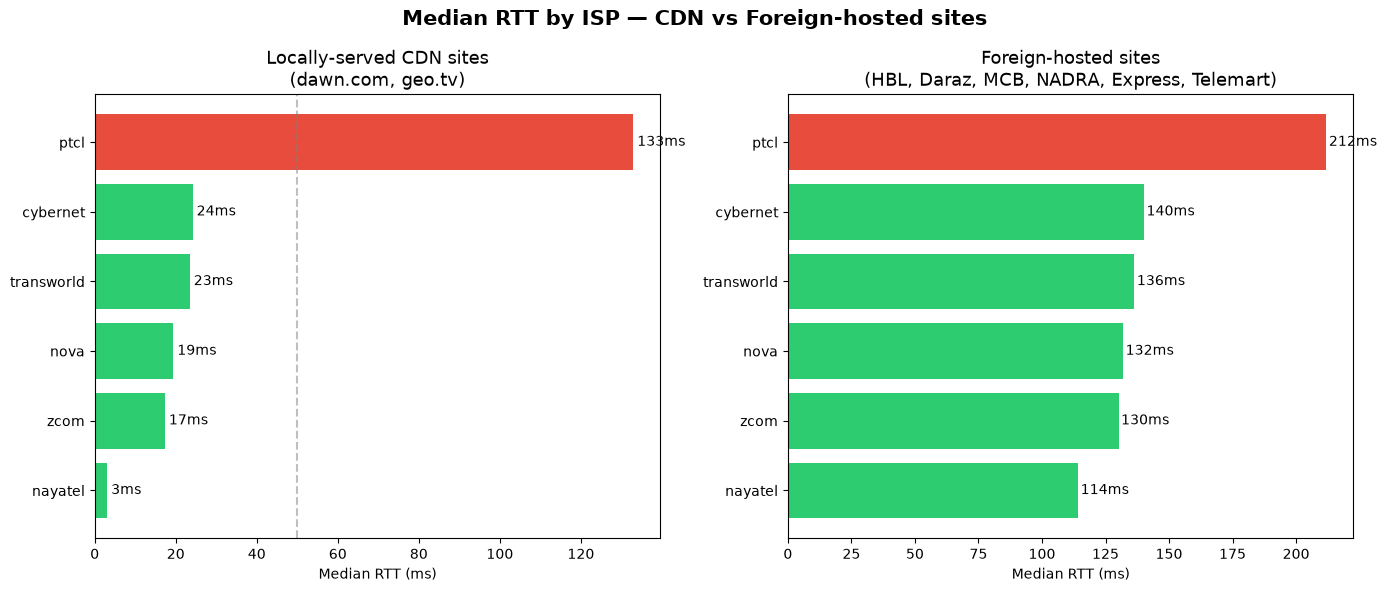

saved to findings/


In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# data
isps = ['nayatel', 'zcom', 'nova', 'transworld', 'cybernet', 'ptcl']
cdn_rtts = [3.055, 17.306, 19.382, 23.451, 24.160, 132.905]
foreign_rtts = [114.234, 130.130, 131.915, 136.347, 140.139, 211.906]

colors = ['#2ecc71' if isp != 'ptcl' else '#e74c3c' for isp in isps]

# left chart - CDN sites
axes[0].barh(isps, cdn_rtts, color=colors)
axes[0].set_title('Locally-served CDN sites\n(dawn.com, geo.tv)', fontsize=13)
axes[0].set_xlabel('Median RTT (ms)')
axes[0].axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50ms threshold')
for i, v in enumerate(cdn_rtts):
    axes[0].text(v + 1, i, f'{v:.0f}ms', va='center', fontsize=10)

# right chart - foreign hosted
axes[1].barh(isps, foreign_rtts, color=colors)
axes[1].set_title('Foreign-hosted sites\n(HBL, Daraz, MCB, NADRA, Express, Telemart)', fontsize=13)
axes[1].set_xlabel('Median RTT (ms)')
for i, v in enumerate(foreign_rtts):
    axes[1].text(v + 1, i, f'{v:.0f}ms', va='center', fontsize=10)

fig.suptitle('Median RTT by ISP — CDN vs Foreign-hosted sites', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../findings/fig_rtt_by_isp_cdn_vs_foreign.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved to findings/")

In [13]:
# median hop count per ISP
print("=== Median hop count per ISP ===")
print(traces.groupby('isp')['total_hops'].median().sort_values())

print("\n=== Median timeout hops per ISP (invisible hops) ===")
print(traces.groupby('isp')['timeout_hops'].median().sort_values())


=== Median hop count per ISP ===
isp
ptcl          3.0
transworld    3.0
zcom          7.5
nayatel       8.0
nova          8.5
cybernet      9.0
Name: total_hops, dtype: float64

=== Median timeout hops per ISP (invisible hops) ===
isp
cybernet      0.0
nova          0.0
zcom          0.0
nayatel       1.0
ptcl          5.0
transworld    5.0
Name: timeout_hops, dtype: float64


In [14]:
# path changes - how many distinct AS paths did each probe/site combo see?
path_stability = traces.groupby(['isp', 'target_hostname'])['asns_in_path'].nunique().reset_index()
path_stability.columns = ['isp', 'site', 'distinct_paths']
path_stability = path_stability.sort_values('distinct_paths', ascending=False)
print(path_stability.head(20))


         isp            site  distinct_paths
8   cybernet    nadra.gov.pk               8
38      ptcl    nadra.gov.pk               4
0   cybernet        daraz.pk               3
31      ptcl        dawn.com               3
58      zcom    nadra.gov.pk               3
39      ptcl     telemart.pk               3
37      ptcl      mcb.com.pk               3
36      ptcl         hbl.com               3
33      ptcl  express.com.pk               3
30      ptcl        daraz.pk               3
4   cybernet      fbr.gov.pk               3
10   nayatel        daraz.pk               2
27      nova      mcb.com.pk               2
2   cybernet    dunyanews.tv               2
57      zcom      mcb.com.pk               2
5   cybernet          geo.tv               2
6   cybernet         hbl.com               2
11   nayatel        dawn.com               2
7   cybernet      mcb.com.pk               2
32      ptcl    dunyanews.tv               2


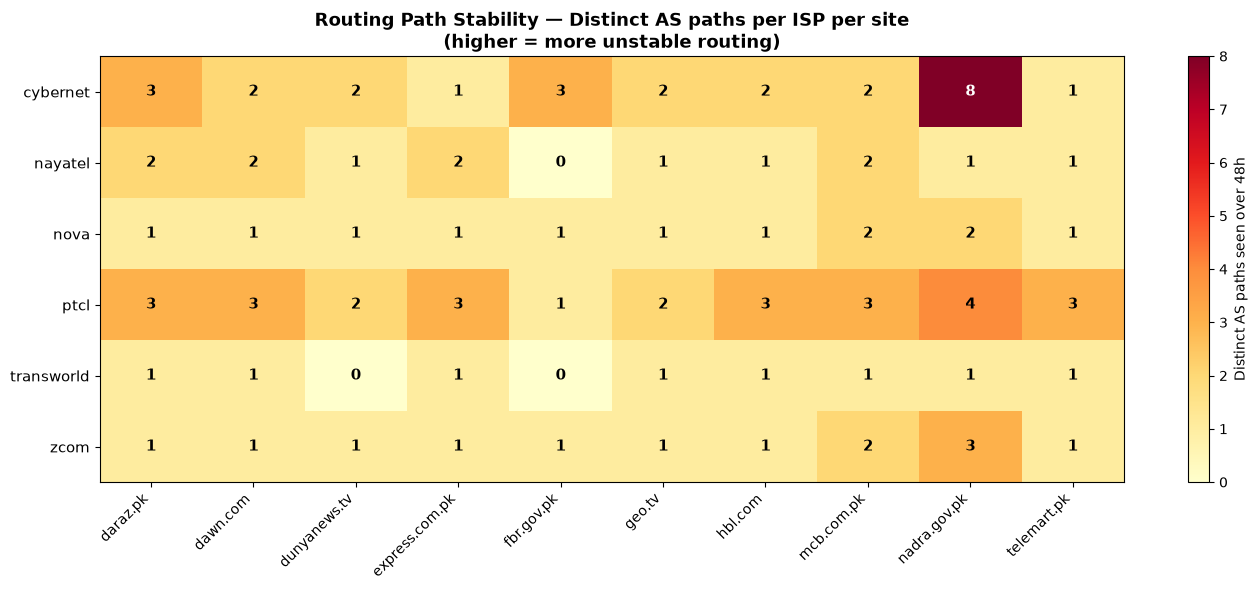

saved


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# pivot to matrix form
pivot = path_stability.pivot(index='isp', columns='site', values='distinct_paths').fillna(1)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

# labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

# add numbers inside cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, int(pivot.values[i, j]),
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if pivot.values[i, j] > 4 else 'black')

plt.colorbar(im, ax=ax, label='Distinct AS paths seen over 48h')
ax.set_title('Routing Path Stability — Distinct AS paths per ISP per site\n(higher = more unstable routing)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../findings/fig_path_stability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved")

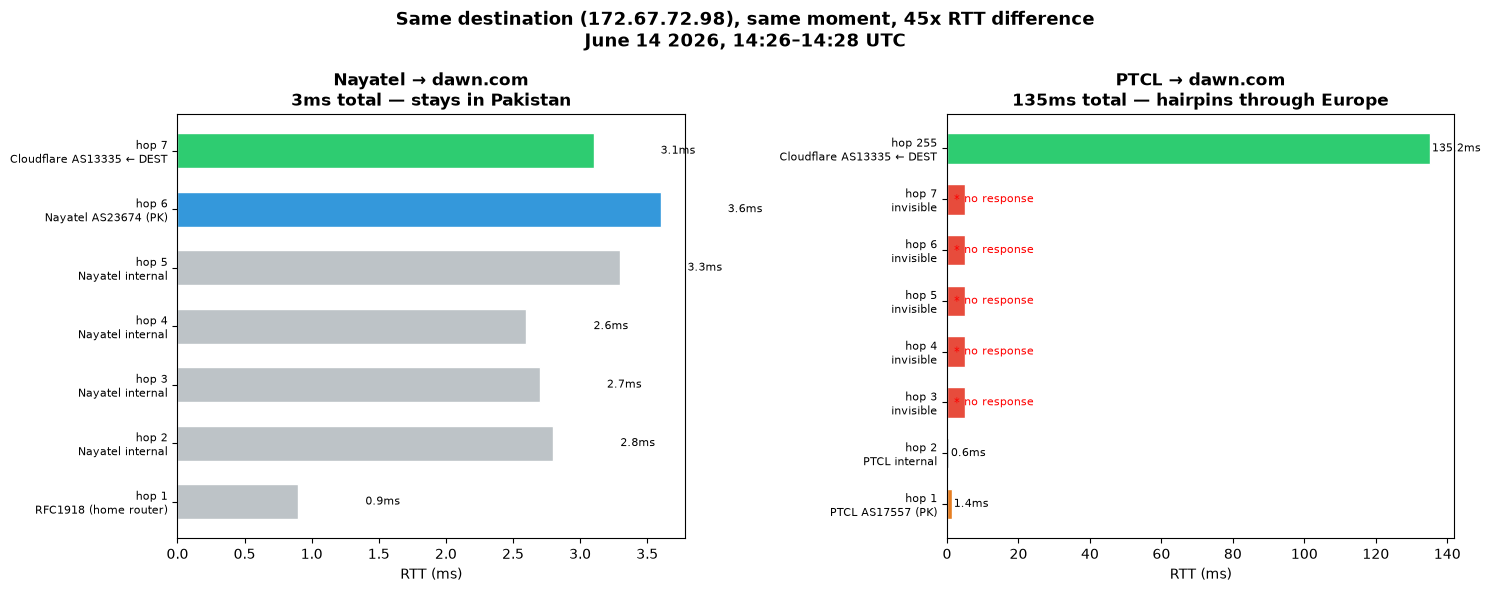

saved


In [16]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Nayatel path
nayatel_hops = [
    (1, 0.9, '192.168.18.1', 'RFC1918 (home router)'),
    (2, 2.8, '100.89.32.1', 'Nayatel internal'),
    (3, 2.7, '172.27.0.29', 'Nayatel internal'),
    (4, 2.6, '172.27.0.22', 'Nayatel internal'),
    (5, 3.3, '172.31.5.253', 'Nayatel internal'),
    (6, 3.6, '203.175.65.67', 'Nayatel AS23674 (PK)'),
    (7, 3.1, '172.67.72.98', 'Cloudflare AS13335 ← DEST'),
]

# PTCL path
ptcl_hops = [
    (1, 1.4, '203.135.63.1', 'PTCL AS17557 (PK)'),
    (2, 0.6, '172.25.3.14', 'PTCL internal'),
    (3, None, '*', 'invisible'),
    (4, None, '*', 'invisible'),
    (5, None, '*', 'invisible'),
    (6, None, '*', 'invisible'),
    (7, None, '*', 'invisible'),
    (255, 135.2, '172.67.72.98', 'Cloudflare AS13335 ← DEST'),
]

def plot_path(ax, hops, title, color):
    hop_nums = [h[0] for h in hops]
    rtts = [h[1] if h[1] is not None else 0 for h in hops]
    labels = [f"hop {h[0]}\n{h[3]}" for h in hops]
    
    colors = []
    for h in hops:
        if 'DEST' in h[3]: colors.append('#2ecc71')
        elif 'invisible' in h[3]: colors.append('#e74c3c')
        elif 'RFC1918' in h[3] or 'internal' in h[3].lower(): colors.append('#bdc3c7')
        else: colors.append(color)
    
    bars = ax.barh(range(len(hops)), 
                   [h[1] if h[1] is not None else 5 for h in hops],
                   color=colors, edgecolor='white', height=0.6)
    
    ax.set_yticks(range(len(hops)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('RTT (ms)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    for i, h in enumerate(hops):
        if h[1] is not None:
            ax.text(h[1] + 0.5, i, f'{h[1]}ms', va='center', fontsize=8)
        else:
            ax.text(2, i, '* no response', va='center', fontsize=8, color='red')

plot_path(axes[0], nayatel_hops, 
          'Nayatel → dawn.com\n3ms total — stays in Pakistan', '#3498db')
plot_path(axes[1], ptcl_hops, 
          'PTCL → dawn.com\n135ms total — hairpins through Europe', '#e67e22')

fig.suptitle('Same destination (172.67.72.98), same moment, 45x RTT difference\n'
             'June 14 2026, 14:26–14:28 UTC', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../findings/fig_nayatel_vs_ptcl_dawn_path.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved")

## Key Finding: PTCL vs Nayatel path to dawn.com

At nearly the same moment (14:26 vs 14:28 UTC, June 14), two probes traced 
the route to the exact same Cloudflare IP (172.67.72.98) serving dawn.com:

- **Nayatel (Islamabad)** reached it in **3ms** via a direct peering hop 
  inside Pakistan — 8 hops, never left the country.
- **PTCL (Lahore)** reached the same IP in **135ms** — 5 hops invisible, 
  traffic hairpinned through Colt Technology (France) and Level 3 (UK) 
  before reaching Cloudflare.

This is a **45x RTT difference** for the same website at the same moment, 
caused entirely by routing — not geography, not server load. Nayatel peers 
directly with Cloudflare; PTCL does not, so PTCL traffic exits Pakistan 
internationally and returns. This is the core PKIX inefficiency this 
research measures.

In [17]:
# check what columns we have that are relevant for BGP validation
print(traces[['trace_time', 'probe_id', 'isp', 'target_ip', 'target_asn', 'asns_in_path']].head(10))

                  trace_time  probe_id         isp        target_ip  \
0  2026-06-14T14:25:33+00:00     62224  transworld    103.125.60.60   
1  2026-06-14T14:25:34+00:00      7613        zcom   172.67.174.102   
2  2026-06-14T14:25:39+00:00      7764        ptcl   47.246.167.168   
3  2026-06-14T14:25:40+00:00   1016126        ptcl  192.124.249.159   
4  2026-06-14T14:25:41+00:00     60223     nayatel    103.125.60.60   
5  2026-06-14T14:25:41+00:00   1015679        nova     2.19.193.138   
6  2026-06-14T14:25:42+00:00   1015679        nova  192.124.249.159   
7  2026-06-14T14:25:43+00:00      7613        zcom     2.19.193.138   
8  2026-06-14T14:25:43+00:00   1016126        ptcl     2.19.193.138   
9  2026-06-14T14:25:48+00:00      7764        ptcl    45.60.109.176   

   target_asn                                  asns_in_path  
0      138424                                           NaN  
1       13335                152605 > 38193 > 58453 > 13335  
2       45102                   